# 验证 GraphCast 低分辨率数据集

这个 notebook 自包含地完成以下工作：

1. 从 `/root/data/dataset` 目录读取候选数据集，并通过下拉框选择待验证文件。
2. 校验待验证数据集与 `2022-01-01` 参考 GraphCast 样本的整体格式是否一致。
3. 允许绝对时间范围、相对时间长度与参考样本不同，但要求 `time` / `datetime` 仍然保持 6 小时步长。
4. 对待验证数据集执行一次 `GraphCast_small` 的 3 步预测。
5. 导出预测值、真实值、差值，并绘制前 3 个目标时次的三联热力图。

其中真实值与预测值热力图会强制使用相同的时间切片和相同的颜色标尺，`diff` 图使用以 0 为中心的对称标尺。

建议在 `GraphCast` conda 环境中运行。


In [1]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import ipywidgets as widgets
import xarray as xr
from IPython.display import Image, display

PROJECT_ROOT = Path("/root/code/gnn-vis/GraphCast/weather-analysis/typhoon-impact-physics-analysis")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REFERENCE_DATASET_PATH = Path(
    "/root/data/dataset/dataset-source-era5_date-2022-01-01_res-1.0_levels-13_steps-04.nc"
)
LOW_RES_PARAMS_PATH = Path(
    "/root/data/params/"
    "params-GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 "
    "- mesh 2to5 - precipitation input and output.npz"
)
STATS_DIR = Path("/root/data/stats")
DATASET_DIR = Path("/root/data/dataset")

# 可选：直接指定文件名，或指定 1-based 索引；都为 None 时默认选第一个，并显示下拉框供交互切换。
CANDIDATE_FILENAME = None
CANDIDATE_INDEX = None

# 本 notebook 固定做 3 个目标时间步的预测，并绘制前 3 张热力图。
EVAL_STEPS = 3
HEATMAP_COUNT = 3
PLOT_VARIABLE = None
PLOT_LEVEL = None

PREFERRED_PLOT_VARIABLES = (
    "2m_temperature",
    "mean_sea_level_pressure",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "total_precipitation_6hr",
)


def load_netcdf_dataset(path: Path) -> xr.Dataset:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        try:
            return xr.open_dataset(path, engine="netcdf4").load()
        except Exception:
            return xr.open_dataset(path).load()


def open_dataset(path: Path) -> xr.Dataset:
    return load_netcdf_dataset(path)


def dataset_layout_summary(ds: xr.Dataset) -> dict[str, object]:
    return {
        "sizes": dict(ds.sizes),
        "coords": {
            name: {
                "dims": tuple(ds.coords[name].dims),
                "dtype": str(ds.coords[name].dtype),
                "shape": tuple(ds.coords[name].shape),
            }
            for name in ds.coords
        },
        "data_vars": {
            name: {
                "dims": tuple(ds[name].dims),
                "dtype": str(ds[name].dtype),
                "shape": tuple(ds[name].shape),
            }
            for name in ds.data_vars
        },
    }


def _layout_frame(summary: dict[str, object], kind: str) -> pd.DataFrame:
    rows = []
    for name, info in summary[kind].items():
        rows.append(
            {
                "name": name,
                "dims": info["dims"],
                "shape": info["shape"],
                "dtype": info["dtype"],
            }
        )
    return pd.DataFrame(rows).sort_values("name").reset_index(drop=True)


def _check_datetime_spacing(values: np.ndarray) -> bool:
    flat = np.asarray(values).reshape(-1)
    if flat.size < 2:
        return True
    return np.all(np.diff(flat) == np.timedelta64(6, "h"))


def _check_relative_time_layout(values: np.ndarray) -> bool:
    flat = np.asarray(values).reshape(-1)
    if flat.size == 0:
        return False
    if flat[0] != np.timedelta64(0, "ns"):
        return False
    if flat.size < 2:
        return True
    return np.all(np.diff(flat) == np.timedelta64(6, "h"))


def _shape_without_time(dims: tuple[str, ...], shape: tuple[int, ...]) -> tuple[int, ...]:
    return tuple(size for dim_name, size in zip(dims, shape) if dim_name != "time")


def _sizes_without_time(sizes: dict[str, int]) -> dict[str, int]:
    return {name: size for name, size in sizes.items() if name != "time"}


def compare_dataset_layout(candidate: xr.Dataset, reference: xr.Dataset) -> list[str]:
    issues: list[str] = []

    candidate_sizes = dict(candidate.sizes)
    reference_sizes = dict(reference.sizes)
    if _sizes_without_time(candidate_sizes) != _sizes_without_time(reference_sizes):
        issues.append(
            "non-time sizes differ: "
            f"candidate={_sizes_without_time(candidate_sizes)}, "
            f"reference={_sizes_without_time(reference_sizes)}"
        )

    if candidate_sizes.get("time", 0) < EVAL_STEPS + 2:
        issues.append(
            f"candidate time dimension is too short for {EVAL_STEPS}-step prediction: "
            f"got {candidate_sizes.get('time', 0)}, need at least {EVAL_STEPS + 2}"
        )

    candidate_coords = set(candidate.coords)
    reference_coords = set(reference.coords)
    if candidate_coords != reference_coords:
        issues.append(
            f"coords differ: candidate={sorted(candidate_coords)}, reference={sorted(reference_coords)}"
        )

    candidate_vars = set(candidate.data_vars)
    reference_vars = set(reference.data_vars)
    if candidate_vars != reference_vars:
        issues.append(
            f"data_vars differ: candidate={sorted(candidate_vars)}, reference={sorted(reference_vars)}"
        )

    for coord_name in sorted(candidate_coords & reference_coords):
        cand = candidate.coords[coord_name]
        ref = reference.coords[coord_name]

        if tuple(cand.dims) != tuple(ref.dims):
            issues.append(
                f"coord {coord_name} dims differ: candidate={cand.dims}, reference={ref.dims}"
            )

        if coord_name == "datetime":
            if _shape_without_time(tuple(cand.dims), tuple(cand.shape)) != _shape_without_time(tuple(ref.dims), tuple(ref.shape)):
                issues.append(
                    f"coord {coord_name} non-time shape differ: candidate={cand.shape}, reference={ref.shape}"
                )
            if np.asarray(cand.values).dtype.kind != "M":
                issues.append(f"coord datetime dtype is not datetime64: {cand.dtype}")
            if not _check_datetime_spacing(cand.values):
                issues.append("coord datetime does not have 6-hour cadence")
            if not _check_datetime_spacing(ref.values):
                issues.append("reference coord datetime does not have 6-hour cadence")
            continue

        if coord_name == "time":
            if cand.dtype != ref.dtype:
                issues.append(f"coord time dtype differ: candidate={cand.dtype}, reference={ref.dtype}")
            if not _check_relative_time_layout(cand.values):
                issues.append("coord time does not start at 0h with 6-hour cadence")
            if not _check_relative_time_layout(ref.values):
                issues.append("reference coord time does not start at 0h with 6-hour cadence")
            continue

        if tuple(cand.shape) != tuple(ref.shape):
            issues.append(
                f"coord {coord_name} shape differ: candidate={cand.shape}, reference={ref.shape}"
            )
        if not np.array_equal(cand.values, ref.values):
            issues.append(f"coord {coord_name} values differ from reference")

    for var_name in sorted(candidate_vars & reference_vars):
        cand = candidate[var_name]
        ref = reference[var_name]
        if tuple(cand.dims) != tuple(ref.dims):
            issues.append(
                f"var {var_name} dims differ: candidate={cand.dims}, reference={ref.dims}"
            )
        if "time" in cand.dims:
            if _shape_without_time(tuple(cand.dims), tuple(cand.shape)) != _shape_without_time(tuple(ref.dims), tuple(ref.shape)):
                issues.append(
                    f"var {var_name} non-time shape differ: candidate={cand.shape}, reference={ref.shape}"
                )
        elif tuple(cand.shape) != tuple(ref.shape):
            issues.append(
                f"var {var_name} shape differ: candidate={cand.shape}, reference={ref.shape}"
            )
        if cand.dtype != ref.dtype:
            issues.append(
                f"var {var_name} dtype differ: candidate={cand.dtype}, reference={ref.dtype}"
            )

    return issues


def list_candidate_datasets(dataset_dir: Path) -> list[Path]:
    if not dataset_dir.exists():
        raise FileNotFoundError(f"数据集目录不存在: {dataset_dir}")
    if not dataset_dir.is_dir():
        raise NotADirectoryError(f"数据集路径不是目录: {dataset_dir}")
    return sorted(path for path in dataset_dir.iterdir() if path.is_file() and path.suffix.lower() == ".nc")


def print_candidate_datasets(dataset_dir: Path, candidates: list[Path]) -> None:
    if not candidates:
        print("目录中没有找到 .nc 数据集。")
        return

    print(f"候选数据集目录: {dataset_dir}")
    for idx, path in enumerate(candidates, start=1):
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"  [{idx}] {path.name} ({size_mb:.2f} MB)")


def candidate_option_label(path: Path) -> str:
    size_mb = path.stat().st_size / (1024 * 1024)
    return f"{path.name} ({size_mb:.2f} MB)"


def set_candidate_dataset(path: Path) -> None:
    global CANDIDATE_DATASET_PATH, EXPORT_DIR
    CANDIDATE_DATASET_PATH = path
    EXPORT_DIR = DATASET_DIR / f"graphcast_validation_{path.stem}"


def resolve_candidate_dataset(
    dataset_dir: Path,
    *,
    candidate_filename: str | None = None,
    candidate_index: int | None = None,
) -> tuple[Path, list[Path]]:
    candidates = list_candidate_datasets(dataset_dir)
    if not candidates:
        raise FileNotFoundError(f"目录中没有可用的 .nc 数据集: {dataset_dir}")

    if candidate_filename is not None and candidate_index is not None:
        raise ValueError("CANDIDATE_FILENAME 和 CANDIDATE_INDEX 只能设置一个。")

    if candidate_filename is not None:
        selected = dataset_dir / candidate_filename
        if not selected.exists():
            raise FileNotFoundError(f"指定的数据集不存在: {selected}")
        return selected, candidates

    if candidate_index is not None:
        if candidate_index < 1 or candidate_index > len(candidates):
            raise ValueError(f"CANDIDATE_INDEX 必须在 [1, {len(candidates)}] 内，当前是 {candidate_index}")
        return candidates[candidate_index - 1], candidates

    return candidates[0], candidates


def display_candidate_dataset_selector(
    dataset_dir: Path,
    candidates: list[Path],
    *,
    selected_path: Path,
):
    set_candidate_dataset(selected_path)
    dropdown = widgets.Dropdown(
        options=[(candidate_option_label(path), str(path)) for path in candidates],
        value=str(selected_path),
        description="待验证数据集",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="95%"),
    )
    selection_summary = widgets.HTML()

    def refresh(selected_value: str) -> None:
        selected = Path(selected_value)
        set_candidate_dataset(selected)
        selection_summary.value = (
            f"<b>候选数据集目录:</b> {dataset_dir}<br>"
            f"<b>当前待验证数据集:</b> {selected.name}<br>"
            f"<b>导出目录:</b> {EXPORT_DIR}<br>"
            "修改下拉选项后，继续运行下面的单元即可。"
        )

    def _on_change(change: dict[str, object]) -> None:
        if change.get("name") == "value" and change.get("new") is not None:
            refresh(str(change["new"]))

    dropdown.observe(_on_change, names="value")
    refresh(str(selected_path))
    selector = widgets.VBox(
        [
            widgets.HTML("<b>选择待验证数据集</b>"),
            dropdown,
            selection_summary,
        ]
    )
    display(selector)
    return dropdown


def describe_dataset(ds: xr.Dataset, *, label: str) -> None:
    print(f"{label} 维度: {dict(ds.sizes)}")
    if "datetime" in ds.coords:
        values = np.asarray(ds["datetime"].values).reshape(-1)
        if values.size:
            print(f"{label} 时间范围: {values[0]} -> {values[-1]} (共 {values.size} 个时次)")


def _build_graphcast_prediction_bundle(
    dataset_path: Path,
    *,
    params_path: Path,
    stats_dir: Path,
    eval_steps: int,
) -> dict[str, object]:
    import jax

    from shared.model_utils import build_run_forward, extract_eval_data, load_checkpoint

    ckpt = load_checkpoint(str(params_path))
    example_batch = load_netcdf_dataset(dataset_path)
    eval_inputs, eval_targets, eval_forcings = extract_eval_data(
        example_batch,
        ckpt.task_config,
        eval_steps=eval_steps,
    )
    diffs_stddev_by_level = load_netcdf_dataset(stats_dir / "stats-diffs_stddev_by_level.nc")
    mean_by_level = load_netcdf_dataset(stats_dir / "stats-mean_by_level.nc")
    stddev_by_level = load_netcdf_dataset(stats_dir / "stats-stddev_by_level.nc")

    run_forward_jitted = build_run_forward(
        ckpt.model_config,
        ckpt.task_config,
        ckpt.params,
        {},
        diffs_stddev_by_level,
        mean_by_level,
        stddev_by_level,
    )

    targets_template = eval_targets * np.nan
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        outputs = run_forward_jitted(
            rng=jax.random.PRNGKey(0),
            inputs=eval_inputs,
            targets_template=targets_template,
            forcings=eval_forcings,
        )

    return {
        "ckpt": ckpt,
        "example_batch": example_batch,
        "eval_inputs": eval_inputs,
        "eval_targets": eval_targets,
        "eval_forcings": eval_forcings,
        "outputs": outputs,
    }


def run_graphcast_minimal(
    dataset_path: Path,
    *,
    params_path: Path,
    stats_dir: Path,
    eval_steps: int,
) -> dict[str, object]:
    bundle = _build_graphcast_prediction_bundle(
        dataset_path,
        params_path=params_path,
        stats_dir=stats_dir,
        eval_steps=eval_steps,
    )
    outputs = bundle["outputs"]
    ckpt = bundle["ckpt"]

    output_vars = tuple(outputs.data_vars)
    expected_vars = tuple(ckpt.task_config.target_variables)
    if set(output_vars) != set(expected_vars):
        raise ValueError(
            f"Unexpected GraphCast outputs: got {output_vars}, expected {expected_vars}"
        )

    sample_var = outputs[output_vars[0]]
    sample_value = float(np.asarray(sample_var.isel(batch=0, time=0).values).reshape(-1)[0])
    if not np.isfinite(sample_value):
        raise ValueError(f"Non-finite sample value from GraphCast output: {sample_value}")

    return {
        "eval_steps": eval_steps,
        "output_sizes": dict(outputs.sizes),
        "output_vars": output_vars,
        "sample_var": output_vars[0],
        "sample_value": sample_value,
    }


def _compute_error_metrics(prediction: np.ndarray, target: np.ndarray) -> dict[str, float]:
    pred = np.asarray(prediction, dtype=np.float64)
    truth = np.asarray(target, dtype=np.float64)
    diff = pred - truth
    return {
        "rmse": float(np.sqrt(np.nanmean(diff ** 2))),
        "mae": float(np.nanmean(np.abs(diff))),
        "bias": float(np.nanmean(diff)),
        "max_abs": float(np.nanmax(np.abs(diff))),
    }


def extract_target_datetime_coord(
    example_batch: xr.Dataset,
    eval_targets: xr.Dataset,
) -> xr.DataArray | None:
    if "datetime" in eval_targets.coords:
        return eval_targets["datetime"]

    if "datetime" not in example_batch.coords:
        return None
    if "time" not in example_batch.coords or "time" not in eval_targets.coords:
        return None

    source_times = np.asarray(example_batch["time"].values)
    target_times = np.asarray(eval_targets["time"].values)
    time_indices: list[int] = []
    for target_time in target_times:
        matches = np.where(source_times == target_time)[0]
        if matches.size != 1:
            return None
        time_indices.append(int(matches[0]))

    return example_batch["datetime"].isel(time=time_indices)


def build_prediction_comparison_datasets(
    outputs: xr.Dataset,
    eval_targets: xr.Dataset,
) -> tuple[xr.Dataset, xr.Dataset]:
    prediction_vars: dict[str, xr.DataArray] = {}
    error_vars: dict[str, xr.DataArray] = {}

    for var_name in eval_targets.data_vars:
        target = eval_targets[var_name]
        prediction = outputs[var_name].transpose(*target.dims)
        aligned_prediction = xr.DataArray(
            prediction.values,
            dims=target.dims,
            coords=target.coords,
            attrs=dict(target.attrs),
        )
        prediction_vars[var_name] = aligned_prediction
        error_vars[var_name] = xr.DataArray(
            (aligned_prediction - target).values,
            dims=target.dims,
            coords=target.coords,
            attrs={
                "long_name": f"{var_name} prediction minus truth",
                "description": "GraphCast prediction minus extracted ERA5 ground truth",
            },
        )

    predictions = xr.Dataset(prediction_vars, coords=eval_targets.coords)
    errors = xr.Dataset(error_vars, coords=eval_targets.coords)
    predictions.attrs = {
        "description": "GraphCast predictions aligned to the extracted target coordinates"
    }
    errors.attrs = {
        "description": "GraphCast prediction minus extracted ERA5 ground truth"
    }
    return predictions, errors


def compare_graphcast_predictions(
    dataset_path: Path,
    *,
    params_path: Path,
    stats_dir: Path,
    eval_steps: int,
) -> dict[str, object]:
    bundle = _build_graphcast_prediction_bundle(
        dataset_path,
        params_path=params_path,
        stats_dir=stats_dir,
        eval_steps=eval_steps,
    )
    outputs = bundle["outputs"]
    eval_targets = bundle["eval_targets"]
    target_datetime_coord = extract_target_datetime_coord(bundle["example_batch"], eval_targets)
    if target_datetime_coord is not None:
        eval_targets = eval_targets.assign_coords(datetime=target_datetime_coord)
    predictions, errors = build_prediction_comparison_datasets(outputs, eval_targets)

    overall: list[dict[str, object]] = []
    by_time: list[dict[str, object]] = []

    for var_name in eval_targets.data_vars:
        target = eval_targets[var_name]
        prediction = predictions[var_name]
        metrics = _compute_error_metrics(prediction.values, target.values)
        overall.append({"variable": var_name, **metrics})

        if "time" in target.dims:
            for time_idx in range(target.sizes["time"]):
                time_pred = prediction.isel(time=time_idx)
                time_target = target.isel(time=time_idx)
                time_metrics = _compute_error_metrics(time_pred.values, time_target.values)
                by_time.append(
                    {
                        "variable": var_name,
                        "time_idx": int(time_idx),
                        "lead_time": str(target["time"].values[time_idx]),
                        **time_metrics,
                    }
                )

    return {
        "overall": overall,
        "by_time": by_time,
        "outputs": outputs,
        "predictions": predictions,
        "targets": eval_targets,
        "errors": errors,
    }


def export_prediction_comparison(
    summary: dict[str, object],
    output_dir: Path,
    *,
    candidate_dataset: Path,
    reference_dataset: Path,
    eval_steps: int,
) -> dict[str, Path]:
    output_dir.mkdir(parents=True, exist_ok=True)

    predictions_path = output_dir / "graphcast_predictions.nc"
    targets_path = output_dir / "graphcast_truth_targets.nc"
    errors_path = output_dir / "graphcast_prediction_minus_truth.nc"
    metrics_path = output_dir / "graphcast_prediction_metrics.json"

    summary["predictions"].to_netcdf(predictions_path)
    summary["targets"].to_netcdf(targets_path)
    summary["errors"].to_netcdf(errors_path)

    metrics_payload = {
        "candidate_dataset": str(candidate_dataset),
        "reference_dataset": str(reference_dataset),
        "eval_steps": eval_steps,
        "overall": summary["overall"],
        "by_time": summary["by_time"],
        "target_variables": list(summary["targets"].data_vars),
        "lead_times": [str(value) for value in summary["targets"]["time"].values],
    }
    if "datetime" in summary["targets"].coords:
        metrics_payload["target_datetimes"] = [
            [str(value) for value in row]
            for row in np.asarray(summary["targets"]["datetime"].values)
        ]
    metrics_path.write_text(
        json.dumps(metrics_payload, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )

    return {
        "predictions": predictions_path,
        "targets": targets_path,
        "errors": errors_path,
        "metrics": metrics_path,
    }


def select_heatmap_slice(
    dataset: xr.Dataset,
    *,
    variable: str,
    time_idx: int,
    level: int | None = None,
) -> xr.DataArray:
    if variable not in dataset.data_vars:
        raise ValueError(
            f"Variable {variable!r} not found. Available variables: {sorted(dataset.data_vars)}"
        )

    field = dataset[variable]
    if "batch" in field.dims:
        field = field.isel(batch=0)

    if "time" not in field.dims:
        raise ValueError(f"变量 {variable!r} 没有 time 维。")
    if time_idx < 0 or time_idx >= field.sizes["time"]:
        raise ValueError(
            f"time_idx={time_idx} 超出变量 {variable!r} 的范围；"
            f"合法区间是 [0, {field.sizes['time'] - 1}]"
        )
    field = field.isel(time=time_idx)

    if "level" in field.dims:
        if level is None:
            raise ValueError(f"变量 {variable!r} 含有 level 维，请设置 PLOT_LEVEL。")
        available_levels = np.asarray(dataset["level"].values)
        if level not in set(np.asarray(available_levels).tolist()):
            raise ValueError(
                f"Level {level} 不在可用层次中，可选值: {available_levels.tolist()}"
            )
        field = field.sel(level=level)
    elif level is not None:
        raise ValueError(f"变量 {variable!r} 不含 level 维，不应设置 PLOT_LEVEL。")

    if tuple(field.dims) != ("lat", "lon"):
        raise ValueError(f"绘图需要二维 lat/lon 切片，当前得到的维度是 {field.dims}。")
    return field


def plot_prediction_heatmaps(
    summary: dict[str, object],
    output_dir: Path,
    *,
    variable: str,
    time_idx: int,
    level: int | None = None,
) -> Path:
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize, TwoSlopeNorm

    predictions = summary["predictions"]
    targets = summary["targets"]
    errors = summary["errors"]

    truth_slice = select_heatmap_slice(targets, variable=variable, time_idx=time_idx, level=level)
    prediction_slice = select_heatmap_slice(predictions, variable=variable, time_idx=time_idx, level=level)
    diff_slice = select_heatmap_slice(errors, variable=variable, time_idx=time_idx, level=level)

    shared_min = float(min(np.nanmin(truth_slice.values), np.nanmin(prediction_slice.values)))
    shared_max = float(max(np.nanmax(truth_slice.values), np.nanmax(prediction_slice.values)))
    if np.isclose(shared_min, shared_max):
        shared_max = shared_min + 1e-6

    diff_abs = float(np.nanmax(np.abs(diff_slice.values)))
    if np.isclose(diff_abs, 0.0):
        diff_abs = 1e-6

    main_norm = Normalize(vmin=shared_min, vmax=shared_max)
    diff_norm = TwoSlopeNorm(vmin=-diff_abs, vcenter=0.0, vmax=diff_abs)
    lat = truth_slice["lat"].values
    lon = truth_slice["lon"].values

    time_label = str(targets["time"].values[time_idx])
    if "datetime" in targets.coords:
        time_label = str(targets["datetime"].isel(batch=0, time=time_idx).values)

    level_suffix = f", level={level}" if level is not None else ""
    units = truth_slice.attrs.get("units")
    units_suffix = f" [{units}]" if units else ""

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    axes[0].pcolormesh(
        lon,
        lat,
        truth_slice.values,
        shading="auto",
        cmap="viridis",
        norm=main_norm,
    )
    pred_mesh = axes[1].pcolormesh(
        lon,
        lat,
        prediction_slice.values,
        shading="auto",
        cmap="viridis",
        norm=main_norm,
    )
    diff_mesh = axes[2].pcolormesh(
        lon,
        lat,
        diff_slice.values,
        shading="auto",
        cmap="coolwarm",
        norm=diff_norm,
    )

    axes[0].set_title("真实值")
    axes[1].set_title("预测值")
    axes[2].set_title("预测值 - 真实值")
    for ax in axes:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    colorbar_main = fig.colorbar(pred_mesh, ax=axes[:2], location="right", shrink=0.9, pad=0.02)
    colorbar_main.set_label(f"{variable}{units_suffix}")
    colorbar_diff = fig.colorbar(diff_mesh, ax=axes[2], location="right", shrink=0.9, pad=0.02)
    colorbar_diff.set_label(f"{variable} diff{units_suffix}")

    fig.suptitle(
        f"{variable}{level_suffix}, time={time_label}, shared_scale=[{shared_min:.3f}, {shared_max:.3f}]",
        fontsize=12,
    )

    output_dir.mkdir(parents=True, exist_ok=True)
    level_part = f"_level-{level}" if level is not None else ""
    plot_path = output_dir / f"graphcast_heatmaps_{variable}_time-{time_idx}{level_part}.png"
    fig.savefig(plot_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    return plot_path


def resolve_plot_variable(targets: xr.Dataset, requested_variable: str | None) -> str:
    if requested_variable is not None:
        return requested_variable

    for variable in PREFERRED_PLOT_VARIABLES:
        if variable in targets.data_vars and "level" not in targets[variable].dims:
            return variable

    for variable in targets.data_vars:
        if "level" not in targets[variable].dims:
            return variable

    return next(iter(targets.data_vars))


for required_path in (REFERENCE_DATASET_PATH, LOW_RES_PARAMS_PATH, STATS_DIR):
    if not required_path.exists():
        raise FileNotFoundError(f"必要路径不存在: {required_path}")

CANDIDATE_DATASET_PATH, CANDIDATE_DATASETS = resolve_candidate_dataset(
    DATASET_DIR,
    candidate_filename=CANDIDATE_FILENAME,
    candidate_index=CANDIDATE_INDEX,
)
CANDIDATE_DATASET_DROPDOWN = display_candidate_dataset_selector(
    DATASET_DIR,
    CANDIDATE_DATASETS,
    selected_path=CANDIDATE_DATASET_PATH,
)

print(f"参考数据集: {REFERENCE_DATASET_PATH}")
print(f"参数文件: {LOW_RES_PARAMS_PATH}")
print(f"统计目录: {STATS_DIR}")
print(f"预测步数: {EVAL_STEPS}")


参考数据集: /root/data/dataset/dataset-source-era5_date-2022-01-01_res-1.0_levels-13_steps-04.nc
参数文件: /root/data/params/params-GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz
统计目录: /root/data/stats
预测步数: 3


In [5]:
reference = open_dataset(REFERENCE_DATASET_PATH)
candidate = open_dataset(CANDIDATE_DATASET_PATH)

candidate_summary = dataset_layout_summary(candidate)
reference_summary = dataset_layout_summary(reference)

describe_dataset(reference, label="参考数据集")
describe_dataset(candidate, label="待验证数据集")

display(_layout_frame(candidate_summary, "coords"))
display(_layout_frame(candidate_summary, "data_vars"))

issues = compare_dataset_layout(candidate, reference)
if issues:
    print("格式校验失败:")
    for issue in issues:
        print(f"- {issue}")
else:
    print("格式校验通过：待验证数据集与参考 GraphCast 数据集整体格式一致；允许时间范围不同。")

datetime_table = pd.DataFrame(
    {
        "待验证绝对时间": pd.Series(candidate["datetime"].values[0]),
        "待验证相对时间": pd.Series(candidate["time"].values),
        "参考绝对时间": pd.Series(reference["datetime"].values[0]),
        "参考相对时间": pd.Series(reference["time"].values),
    }
)
display(datetime_table)

# 预览几个关键变量，确认数据值和维度正常。
display(candidate["mean_sea_level_pressure"].isel(batch=0, time=0))
display(candidate["2m_temperature"].isel(batch=0, time=0))
display(candidate["temperature"].isel(batch=0, time=0, level=7))


参考数据集 维度: {'lon': 360, 'lat': 181, 'level': 13, 'time': 6, 'batch': 1}
参考数据集 时间范围: 2022-01-01T00:00:00.000000000 -> 2022-01-02T06:00:00.000000000 (共 6 个时次)
待验证数据集 维度: {'lat': 181, 'lon': 360, 'batch': 1, 'time': 25, 'level': 13}
待验证数据集 时间范围: 2021-05-13T06:00:00.000000000 -> 2021-05-19T06:00:00.000000000 (共 25 个时次)


,name,dims,shape,dtype
0,datetime,"(batch, time)","(1, 25)",datetime64[ns]
1,lat,"(lat,)","(181,)",float32
2,level,"(level,)","(13,)",int32
3,lon,"(lon,)","(360,)",float32
4,time,"(time,)","(25,)",timedelta64[ns]


,name,dims,shape,dtype
0,10m_u_component_of_wind,"(batch, time, lat, lon)","(1, 25, 181, 360)",float32
1,10m_v_component_of_wind,"(batch, time, lat, lon)","(1, 25, 181, 360)",float32
2,2m_temperature,"(batch, time, lat, lon)","(1, 25, 181, 360)",float32
3,geopotential,"(batch, time, level, lat, lon)","(1, 25, 13, 181, 360)",float32
4,geopotential_at_surface,"(lat, lon)","(181, 360)",float32
5,land_sea_mask,"(lat, lon)","(181, 360)",float32
6,mean_sea_level_pressure,"(batch, time, lat, lon)","(1, 25, 181, 360)",float32
7,specific_humidity,"(batch, time, level, lat, lon)","(1, 25, 13, 181, 360)",float32
8,temperature,"(batch, time, level, lat, lon)","(1, 25, 13, 181, 360)",float32
9,toa_incident_solar_radiation,"(batch, time, lat, lon)","(1, 25, 181, 360)",float32


格式校验通过：待验证数据集与参考 GraphCast 数据集整体格式一致；允许时间范围不同。


,待验证绝对时间,待验证相对时间,参考绝对时间,参考相对时间
0,2021-05-13 06:00:00,0 days 00:00:00,2022-01-01 00:00:00,0 days 00:00:00
1,2021-05-13 12:00:00,0 days 06:00:00,2022-01-01 06:00:00,0 days 06:00:00
2,2021-05-13 18:00:00,0 days 12:00:00,2022-01-01 12:00:00,0 days 12:00:00
3,2021-05-14 00:00:00,0 days 18:00:00,2022-01-01 18:00:00,0 days 18:00:00
4,2021-05-14 06:00:00,1 days 00:00:00,2022-01-02 00:00:00,1 days 00:00:00
5,2021-05-14 12:00:00,1 days 06:00:00,2022-01-02 06:00:00,1 days 06:00:00
6,2021-05-14 18:00:00,1 days 12:00:00,NaT,NaT
7,2021-05-15 00:00:00,1 days 18:00:00,NaT,NaT
8,2021-05-15 06:00:00,2 days 00:00:00,NaT,NaT
9,2021-05-15 12:00:00,2 days 06:00:00,NaT,NaT


<xarray.DataArray 'mean_sea_level_pressure' (lat: 181, lon: 360)> Size: 261kB
array([[100218.16 , 100218.664, 100219.25 , ..., 100216.836, 100217.266,
        100217.66 ],
       [100183.16 , 100183.79 , 100184.35 , ..., 100180.8  , 100181.57 ,
        100182.41 ],
       [100166.93 , 100165.94 , 100163.89 , ..., 100156.8  , 100160.42 ,
        100164.   ],
       ...,
       [100548.09 , 100539.54 , 100530.766, ..., 100571.766, 100564.08 ,
        100556.25 ],
       [100336.875, 100332.4  , 100327.86 , ..., 100349.89 , 100345.64 ,
        100341.25 ],
       [100243.336, 100241.99 , 100240.64 , ..., 100247.45 , 100246.06 ,
        100244.69 ]], dtype=float32)
Coordinates:
  * lat       (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon       (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    time      timedelta64[ns] 8B 00:00:00
    datetime  datetime64[ns] 8B 2021-05-13T06:00:00

<xarray.DataArray '2m_temperature' (lat: 181, lon: 360)> Size: 261kB
array([[220.10439, 220.10294, 220.10281, ..., 220.09335, 220.09813,
        220.10216],
       [222.36049, 222.33455, 222.30568, ..., 222.39058, 222.38235,
        222.37321],
       [225.03375, 225.00693, 224.9839 , ..., 225.03365, 225.04173,
        225.04398],
       ...,
       [262.6272 , 262.67407, 262.72296, ..., 262.51508, 262.54877,
        262.58643],
       [264.8517 , 264.87845, 264.9063 , ..., 264.78378, 264.80536,
        264.82788],
       [266.2237 , 266.2305 , 266.23535, ..., 266.20407, 266.20966,
        266.2166 ]], dtype=float32)
Coordinates:
  * lat       (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon       (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    time      timedelta64[ns] 8B 00:00:00
    datetime  datetime64[ns] 8B 2021-05-13T06:00:00

<xarray.DataArray 'temperature' (lat: 181, lon: 360)> Size: 261kB
array([[224.9542 , 224.95477, 224.95573, ..., 224.95193, 224.95274,
        224.95345],
       [225.13602, 225.13625, 225.13667, ..., 225.13487, 225.13535,
        225.1357 ],
       [225.85233, 225.8625 , 225.87245, ..., 225.81798, 225.83   ,
        225.84146],
       ...,
       [238.14186, 238.14464, 238.14853, ..., 238.14069, 238.13971,
        238.14023],
       [239.13431, 239.1381 , 239.14182, ..., 239.12592, 239.12839,
        239.13123],
       [239.91629, 239.91748, 239.919  , ..., 239.91226, 239.91339,
        239.91446]], dtype=float32)
Coordinates:
  * lat       (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon       (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    level     int32 4B 500
    time      timedelta64[ns] 8B 00:00:00
    datetime  datetime64[ns] 8B 2021-05-13T06:00:00

## 最小 GraphCast 前向验证

这里固定对待验证数据集执行 **3 个目标时间步** 的前向推理。

第一次运行会触发 JIT 编译，可能需要一点时间。


In [3]:
run_summary = run_graphcast_minimal(
    CANDIDATE_DATASET_PATH,
    params_path=LOW_RES_PARAMS_PATH,
    stats_dir=STATS_DIR,
    eval_steps=EVAL_STEPS,
)
run_summary


{'eval_steps': 3,
 'output_sizes': {'time': 3, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13},
 'output_vars': ('10m_u_component_of_wind',
  '10m_v_component_of_wind',
  '2m_temperature',
  'geopotential',
  'mean_sea_level_pressure',
  'specific_humidity',
  'temperature',
  'total_precipitation_6hr',
  'u_component_of_wind',
  'v_component_of_wind',
  'vertical_velocity'),
 'sample_var': '10m_u_component_of_wind',
 'sample_value': 3.9018447399139404}

## 真实值、预测值与热力图

下面这一步会同时导出三份对齐后的数据文件：

- `graphcast_truth_targets.nc`
- `graphcast_predictions.nc`
- `graphcast_prediction_minus_truth.nc`

然后再对前 3 个目标时次分别绘制三联热力图。
默认优先绘制 `2m_temperature`；如果它不存在，就自动选择其他表面变量。


导出的对齐结果文件:
- predictions: /root/data/dataset/graphcast_validation_dataset-source-era5_date-2021-05-13_res-1.0_levels-13_steps-23/graphcast_predictions.nc
- targets: /root/data/dataset/graphcast_validation_dataset-source-era5_date-2021-05-13_res-1.0_levels-13_steps-23/graphcast_truth_targets.nc
- errors: /root/data/dataset/graphcast_validation_dataset-source-era5_date-2021-05-13_res-1.0_levels-13_steps-23/graphcast_prediction_minus_truth.nc
- metrics: /root/data/dataset/graphcast_validation_dataset-source-era5_date-2021-05-13_res-1.0_levels-13_steps-23/graphcast_prediction_metrics.json


,variable,rmse,mae,bias,max_abs
0,10m_u_component_of_wind,0.641735,0.442768,-1.953103e-02,8.446450
1,10m_v_component_of_wind,0.684463,0.459409,8.306268e-03,8.446261
2,2m_temperature,0.609567,0.390247,1.264545e-02,9.001068
3,geopotential,40.939841,29.059292,-5.435337e+00,571.799805
4,mean_sea_level_pressure,50.132380,32.993392,-4.987398e+00,1206.367188
5,specific_humidity,0.000211,0.000088,-4.414517e-07,0.007262
6,temperature,0.462418,0.321763,-4.873532e-03,11.130569
7,total_precipitation_6hr,0.000724,0.000241,6.900764e-05,0.039124
8,u_component_of_wind,1.463624,0.906755,-1.995528e-02,27.089697
9,v_component_of_wind,1.541877,0.933481,6.070476e-03,32.423393


,variable,time_idx,lead_time,rmse,mae,bias,max_abs
0,10m_u_component_of_wind,0,21600000000000 nanoseconds,0.467730,0.314698,-1.681062e-02,3.957571
1,10m_u_component_of_wind,1,43200000000000 nanoseconds,0.674532,0.481998,-2.259742e-03,5.855727
2,10m_u_component_of_wind,2,64800000000000 nanoseconds,0.749472,0.531607,-3.952274e-02,8.446450
3,10m_v_component_of_wind,0,21600000000000 nanoseconds,0.510760,0.326080,1.225855e-02,7.023642
4,10m_v_component_of_wind,1,43200000000000 nanoseconds,0.732458,0.509279,4.568726e-03,6.638444
5,10m_v_component_of_wind,2,64800000000000 nanoseconds,0.779806,0.542868,8.091529e-03,8.446261
6,2m_temperature,0,21600000000000 nanoseconds,0.540990,0.340232,9.420882e-03,9.001068
7,2m_temperature,1,43200000000000 nanoseconds,0.627240,0.403450,1.762617e-02,6.845886
8,2m_temperature,2,64800000000000 nanoseconds,0.654687,0.427061,1.088930e-02,6.582550
9,geopotential,0,21600000000000 nanoseconds,27.636368,20.286492,-3.703016e+00,260.878540


绘图变量: 2m_temperature
绘制热力图数量: 3


/tmp/ipykernel_51702/3730476198.py:714: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_path, dpi=160, bbox_inches="tight")
/tmp/ipykernel_51702/3730476198.py:714: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_path, dpi=160, bbox_inches="tight")
/tmp/ipykernel_51702/3730476198.py:714: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_path, dpi=160, bbox_inches="tight")
/tmp/ipykernel_51702/3730476198.py:714: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_path, dpi=160, bbox_inches="tight")
/tmp/ipykernel_51702/3730476198.py:714: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_path, dpi=160, bbox_inches="tight")


热力图已保存到: /root/data/dataset/graphcast_validation_dataset-source-era5_date-2021-05-13_res-1.0_levels-13_steps-23/graphcast_heatmaps_2m_temperature_time-0.png


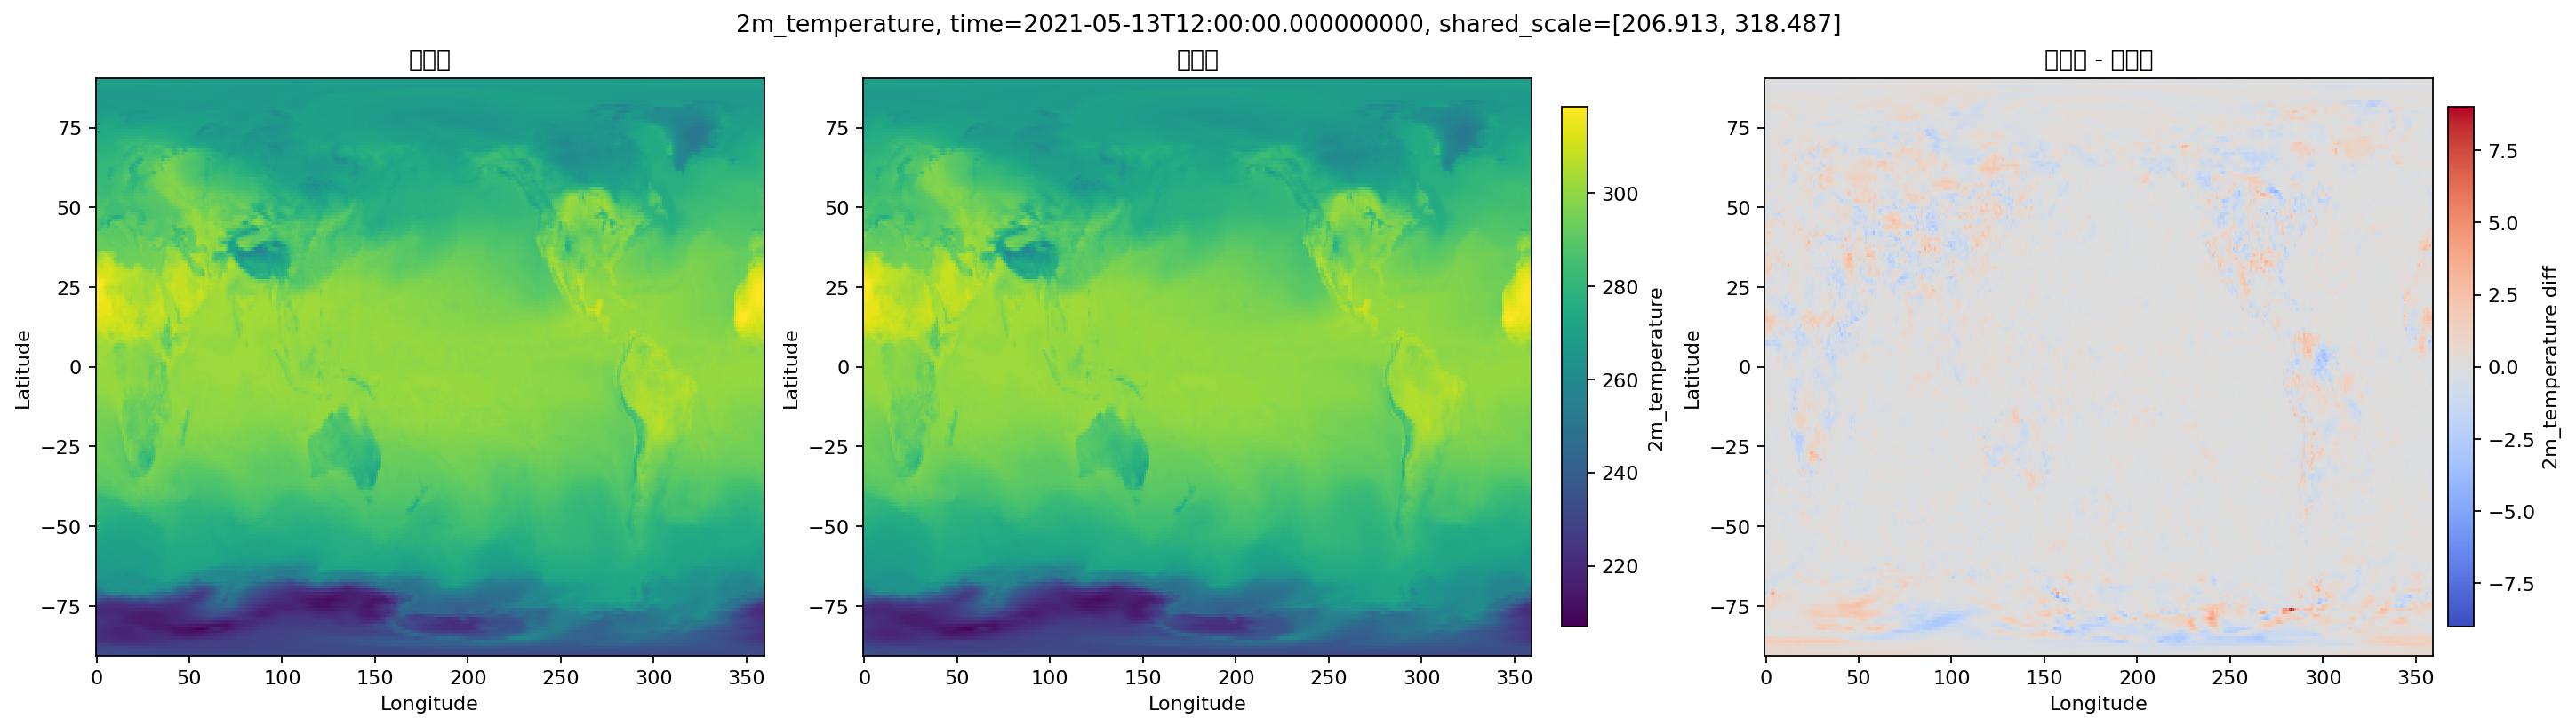

热力图已保存到: /root/data/dataset/graphcast_validation_dataset-source-era5_date-2021-05-13_res-1.0_levels-13_steps-23/graphcast_heatmaps_2m_temperature_time-1.png


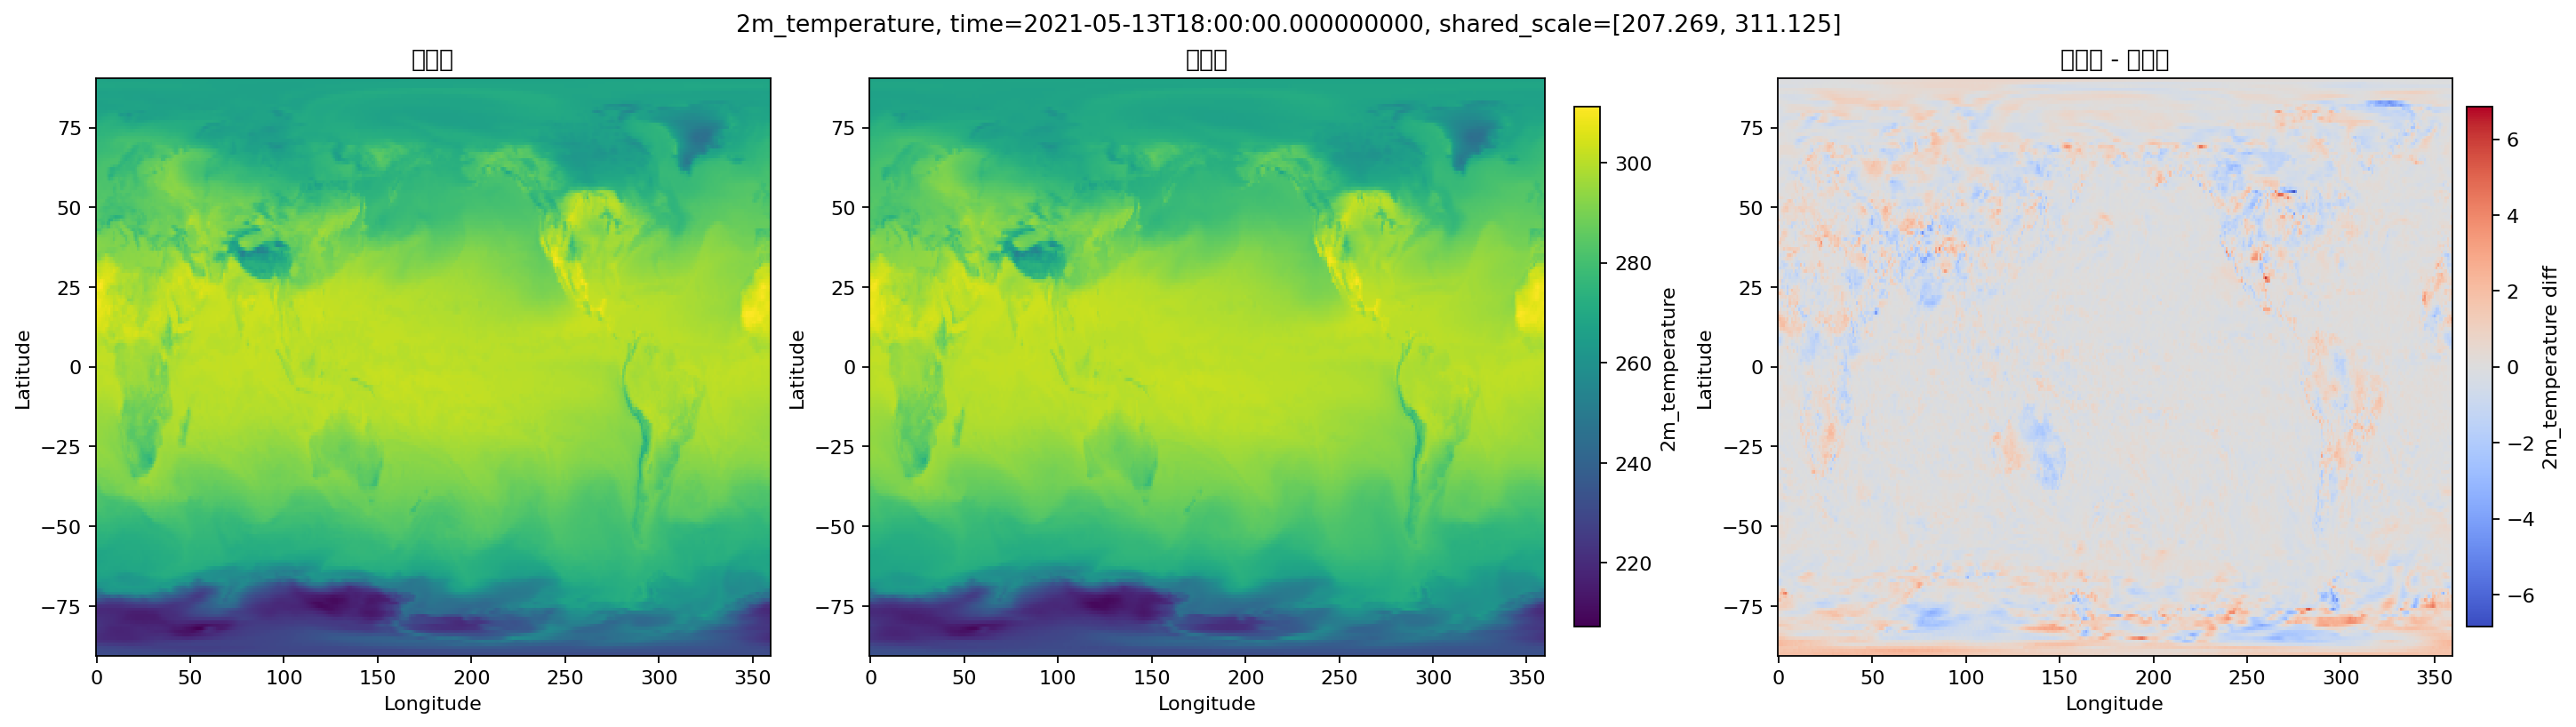

热力图已保存到: /root/data/dataset/graphcast_validation_dataset-source-era5_date-2021-05-13_res-1.0_levels-13_steps-23/graphcast_heatmaps_2m_temperature_time-2.png


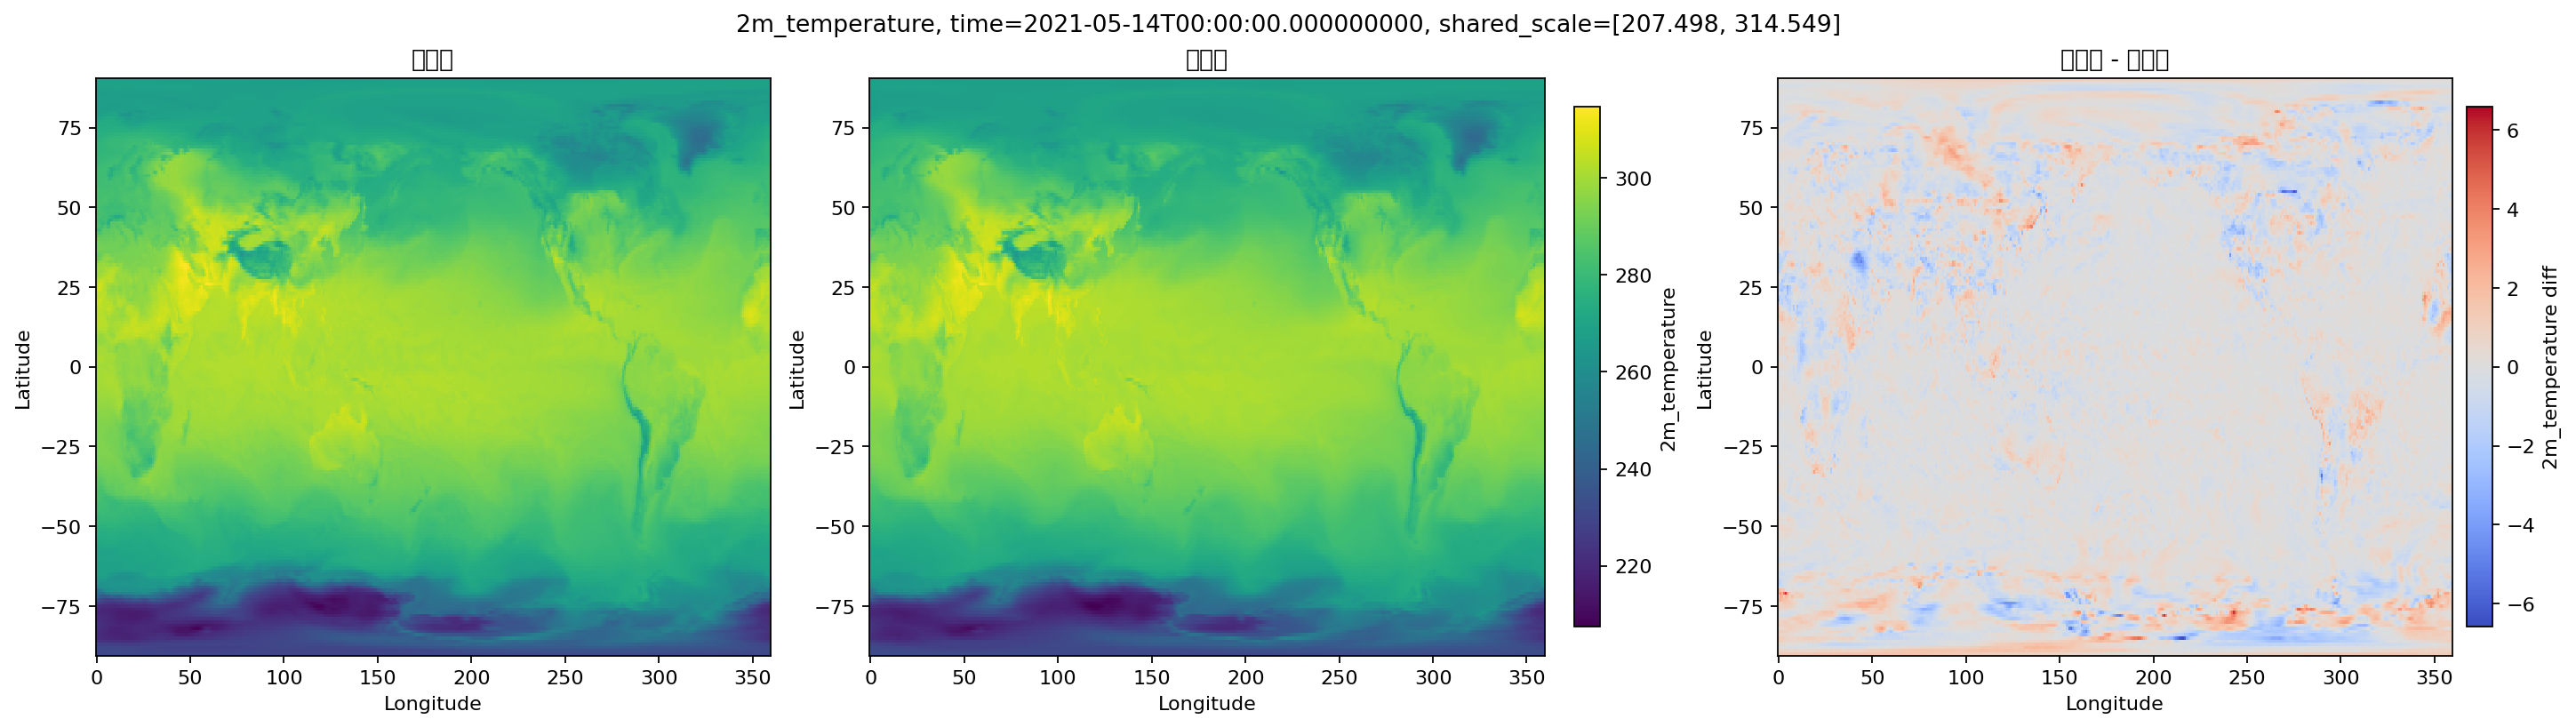

[PosixPath('/root/data/dataset/graphcast_validation_dataset-source-era5_date-2021-05-13_res-1.0_levels-13_steps-23/graphcast_heatmaps_2m_temperature_time-0.png'),
 PosixPath('/root/data/dataset/graphcast_validation_dataset-source-era5_date-2021-05-13_res-1.0_levels-13_steps-23/graphcast_heatmaps_2m_temperature_time-1.png'),
 PosixPath('/root/data/dataset/graphcast_validation_dataset-source-era5_date-2021-05-13_res-1.0_levels-13_steps-23/graphcast_heatmaps_2m_temperature_time-2.png')]

In [4]:
comparison = compare_graphcast_predictions(
    CANDIDATE_DATASET_PATH,
    params_path=LOW_RES_PARAMS_PATH,
    stats_dir=STATS_DIR,
    eval_steps=EVAL_STEPS,
)
exported_paths = export_prediction_comparison(
    comparison,
    EXPORT_DIR,
    candidate_dataset=CANDIDATE_DATASET_PATH,
    reference_dataset=REFERENCE_DATASET_PATH,
    eval_steps=EVAL_STEPS,
)

print("导出的对齐结果文件:")
for name, path in exported_paths.items():
    print(f"- {name}: {path}")

overall_metrics = pd.DataFrame(comparison["overall"]).sort_values("variable").reset_index(drop=True)
by_time_metrics = pd.DataFrame(comparison["by_time"]).sort_values(["variable", "time_idx"]).reset_index(drop=True)

display(overall_metrics)
display(by_time_metrics)

plot_variable = resolve_plot_variable(comparison["targets"], requested_variable=PLOT_VARIABLE)
plot_count = min(HEATMAP_COUNT, int(comparison["targets"].sizes.get("time", 0)))
print(f"绘图变量: {plot_variable}")
print(f"绘制热力图数量: {plot_count}")

heatmap_paths = []
for time_idx in range(plot_count):
    plot_path = plot_prediction_heatmaps(
        comparison,
        EXPORT_DIR,
        variable=plot_variable,
        time_idx=time_idx,
        level=PLOT_LEVEL,
    )
    heatmap_paths.append(plot_path)
    print(f"热力图已保存到: {plot_path}")
    display(Image(filename=str(plot_path)))

heatmap_paths
